# Stage 5 — Segmentation and PhoBERT Tokenization Analysis

This notebook analyzes how controlled noisy Vietnamese text affects the input pipeline before model evaluation.

Stage 5 does **not** train or evaluate classifiers. It measures text-level changes caused by noise:

1. segmentation/word count changes,
2. PhoBERT subword tokenization changes,
3. subword inflation ratio,
4. examples with strong tokenization shifts.

The default segmentation mode is `whitespace` for reproducibility. If an external Vietnamese segmenter is configured, the report will state that explicitly.


## 1. Imports and project paths

In [1]:
from pathlib import Path
from datetime import datetime
import json
import sys

import pandas as pd
import matplotlib.pyplot as plt
import yaml

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "05_segmentation_tokenization_config.yaml"

from src.tokenization_analysis import (
    build_segmenter,
    build_phobert_tokenizer,
    load_noisy_files,
    analyze_noisy_dataframe,
    summarize_analysis,
    summarize_changed_only,
    select_high_inflation_examples,
)

print("Project root:", PROJECT_ROOT)
print("Config path:", CONFIG_PATH)


Project root: d:\project-ml-engineering\nlp-phobert-student-feedback
Config path: d:\project-ml-engineering\nlp-phobert-student-feedback\configs\05_segmentation_tokenization_config.yaml


## 2. Load config and Stage 4 noisy files

In [2]:
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Missing config: {CONFIG_PATH}")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

source_cfg = config["source"]
output_cfg = config["output"]

CLEAN_TEST_PATH = PROJECT_ROOT / source_cfg["clean_test_path"]
NOISY_DIR = PROJECT_ROOT / source_cfg["noisy_dir"]
NOISY_PATTERN = source_cfg.get("noisy_file_pattern", "04_test_*.csv")

TABLES_DIR = PROJECT_ROOT / output_cfg["reports_tables_dir"]
FIGURES_DIR = PROJECT_ROOT / output_cfg["reports_figures_dir"]
NOTES_DIR = PROJECT_ROOT / output_cfg["reports_notes_dir"]

for path in [TABLES_DIR, FIGURES_DIR, NOTES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

if not CLEAN_TEST_PATH.exists():
    raise FileNotFoundError(f"Missing clean test file: {CLEAN_TEST_PATH}")

clean_test_df = pd.read_csv(CLEAN_TEST_PATH)
noisy_frames = load_noisy_files(NOISY_DIR, NOISY_PATTERN)

print("Clean test shape:", clean_test_df.shape)
print("Noisy files loaded:")
for noise_type, df in noisy_frames.items():
    print(f"- {noise_type}: {df.shape}")

display(clean_test_df.head())
config


Clean test shape: (3166, 9)
Noisy files loaded:
- domain_abbreviation: (3166, 15)
- elongation: (3166, 15)
- mixed_noise: (3166, 15)
- no_accent: (3166, 15)
- teencode_colloquial: (3166, 15)
- typo: (3166, 15)


,id,split,text,sentiment_label_raw,sentiment_label,topic_label_raw,topic_label,char_count,raw_word_count
0,test_0,test,nói tiếng anh lưu loát .,2,positive,0,lecturer,24,6
1,test_1,test,giáo viên rất vui tính .,2,positive,0,lecturer,24,6
2,test_2,test,cô max có tâm .,2,positive,0,lecturer,15,5
3,test_3,test,"giảng bài thu hút , dí dỏm .",2,positive,0,lecturer,28,8
4,test_4,test,"giáo viên không giảng dạy kiến thức , hướng dẫ...",0,negative,0,lecturer,79,17


{'source': {'clean_test_path': 'data/processed/test.csv',
  'noisy_dir': 'data/noisy',
  'noisy_file_pattern': '04_test_*.csv'},
 'output': {'reports_tables_dir': 'reports/tables',
  'reports_figures_dir': 'reports/figures',
  'reports_notes_dir': 'reports/notes'},
 'tokenization': {'phobert_model_name': 'vinai/phobert-base',
  'use_phobert_tokenizer': True},
 'segmentation': {'method': 'whitespace',
  'py_vncorenlp_model_dir': 'data/external/vncorenlp'},
 'analysis': {'top_examples_per_noise_type': 15,
  'high_inflation_quantile': 0.95,
  'changed_only_analysis': True}}

## 3. Initialize segmentation and PhoBERT tokenizer

In [3]:
seg_cfg = config.get("segmentation", {})
tok_cfg = config.get("tokenization", {})

segmenter = build_segmenter(
    method=seg_cfg.get("method", "whitespace"),
    py_vncorenlp_model_dir=str(PROJECT_ROOT / seg_cfg.get("py_vncorenlp_model_dir", "data/external/vncorenlp")),
)

tokenizer = build_phobert_tokenizer(
    model_name=tok_cfg.get("phobert_model_name", "vinai/phobert-base"),
    use_phobert_tokenizer=bool(tok_cfg.get("use_phobert_tokenizer", True)),
)

print("Segmentation method:", segmenter.method)
print("Tokenizer source:", tokenizer.source)

sample_text = clean_test_df["text"].iloc[0]
print("\nSample text:", sample_text)
print("Segments:", segmenter.segment(sample_text))
print("Subwords:", tokenizer.tokenize(sample_text))


Segmentation method: whitespace
Tokenizer source: vinai/phobert-base

Sample text: nói tiếng anh lưu loát .
Segments: ['nói', 'tiếng', 'anh', 'lưu', 'loát', '.']
Subwords: ['nói', 'tiếng', 'anh', 'lưu', 'loát', '.']


c:\Users\LENOVO\anaconda3\envs\nlp-phobert-feedback\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


## 4. Run analysis for all noisy datasets

In [4]:
analysis_frames = []

for noise_type, noisy_df in noisy_frames.items():
    print("\n" + "=" * 100)
    print("Analyzing:", noise_type)

    analysis_df = analyze_noisy_dataframe(
        noisy_df=noisy_df,
        segmenter=segmenter,
        tokenizer=tokenizer,
    )

    output_path = TABLES_DIR / f"05_tokenization_analysis_{noise_type}.csv"
    analysis_df.to_csv(output_path, index=False, encoding="utf-8-sig")

    print("Saved:", output_path)
    print("Shape:", analysis_df.shape)

    display(analysis_df[[
        "id",
        "noise_type",
        "changed_token_ratio",
        "num_subwords_clean",
        "num_subwords_noisy",
        "subword_delta",
        "subword_inflation_ratio",
    ]].head())

    analysis_frames.append(analysis_df)

all_analysis = pd.concat(analysis_frames, ignore_index=True)

all_analysis_path = TABLES_DIR / "05_segmentation_tokenization_analysis.csv"
all_analysis.to_csv(all_analysis_path, index=False, encoding="utf-8-sig")

print("\nSaved:", all_analysis_path)
print("All analysis shape:", all_analysis.shape)



Analyzing: domain_abbreviation
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\05_tokenization_analysis_domain_abbreviation.csv
Shape: (3166, 26)


,id,noise_type,changed_token_ratio,num_subwords_clean,num_subwords_noisy,subword_delta,subword_inflation_ratio
0,test_0,domain_abbreviation,0.000000,6,6,0,1.000000
1,test_1,domain_abbreviation,0.333333,6,6,0,1.000000
2,test_2,domain_abbreviation,0.000000,5,5,0,1.000000
3,test_3,domain_abbreviation,0.000000,8,8,0,1.000000
4,test_4,domain_abbreviation,0.235294,17,16,-1,0.941176



Analyzing: elongation
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\05_tokenization_analysis_elongation.csv
Shape: (3166, 26)


,id,noise_type,changed_token_ratio,num_subwords_clean,num_subwords_noisy,subword_delta,subword_inflation_ratio
0,test_0,elongation,0.166667,6,7,1,1.166667
1,test_1,elongation,0.166667,6,8,2,1.333333
2,test_2,elongation,0.200000,5,6,1,1.200000
3,test_3,elongation,0.125000,8,10,2,1.250000
4,test_4,elongation,0.058824,17,20,3,1.176471



Analyzing: mixed_noise
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\05_tokenization_analysis_mixed_noise.csv
Shape: (3166, 26)


...


Analyzing: teencode_colloquial
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\05_tokenization_analysis_teencode_colloquial.csv
Shape: (3166, 26)


,id,noise_type,changed_token_ratio,num_subwords_clean,num_subwords_noisy,subword_delta,subword_inflation_ratio
0,test_0,teencode_colloquial,0.000000,6,6,0,1.0
1,test_1,teencode_colloquial,0.166667,6,6,0,1.0
2,test_2,teencode_colloquial,0.000000,5,5,0,1.0
3,test_3,teencode_colloquial,0.000000,8,8,0,1.0
4,test_4,teencode_colloquial,0.058824,17,17,0,1.0



Analyzing: typo
Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\05_tokenization_analysis_typo.csv
Shape: (3166, 26)


,id,noise_type,changed_token_ratio,num_subwords_clean,num_subwords_noisy,subword_delta,subword_inflation_ratio
0,test_0,typo,0.166667,6,7,1,1.166667
1,test_1,typo,0.166667,6,6,0,1.000000
2,test_2,typo,0.000000,5,5,0,1.000000
3,test_3,typo,0.125000,8,8,0,1.000000
4,test_4,typo,0.058824,17,17,0,1.000000



Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\05_segmentation_tokenization_analysis.csv
All analysis shape: (18996, 26)


## 5. Summary tables

In [5]:
summary_df = summarize_analysis(all_analysis)

summary_path = TABLES_DIR / "05_segmentation_tokenization_summary.csv"
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")

display(summary_df.round(4))
print("Saved:", summary_path)

changed_only_summary = summarize_changed_only(all_analysis)

changed_only_path = TABLES_DIR / "05_segmentation_tokenization_changed_only_summary.csv"
changed_only_summary.to_csv(changed_only_path, index=False, encoding="utf-8-sig")

display(changed_only_summary.round(4))
print("Saved:", changed_only_path)


,noise_type,num_rows,num_changed_rows,mean_changed_token_ratio,mean_segment_delta,median_segment_delta,segmentation_change_rate,mean_segmentation_jaccard_distance,mean_subword_delta,median_subword_delta,mean_subword_inflation_ratio,median_subword_inflation_ratio,subword_change_rate,mean_subword_jaccard_distance
0,domain_abbreviation,3166,1530,0.0902,-0.6415,0.0,48.2628,0.1159,-0.0850,0.0,0.9945,1.0000,48.2628,0.1374
1,elongation,3166,3164,0.1019,0.0000,0.0,99.9368,0.1799,2.1295,2.0,1.2166,1.1765,99.9368,0.2929
2,mixed_noise,3166,3135,0.2089,-0.4899,0.0,99.0208,0.3103,1.3714,1.0,1.1363,1.1000,99.0208,0.3813
3,no_accent,3166,3162,0.7583,0.0000,0.0,99.8737,0.8591,3.5158,3.0,1.2367,1.2308,99.8737,0.8679
4,teencode_colloquial,3166,1541,0.0484,0.0000,0.0,48.5786,0.0848,0.1775,0.0,1.0135,1.0000,48.5786,0.0923
5,typo,3166,3074,0.0956,0.0000,0.0,97.0941,0.1693,0.5332,1.0,1.0516,1.0282,97.0941,0.2010


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\05_segmentation_tokenization_summary.csv


,noise_type,num_changed_subset_rows,num_changed_rows,mean_changed_token_ratio,mean_segment_delta,median_segment_delta,segmentation_change_rate,mean_segmentation_jaccard_distance,mean_subword_delta,median_subword_delta,mean_subword_inflation_ratio,median_subword_inflation_ratio,subword_change_rate,mean_subword_jaccard_distance
0,domain_abbreviation,1530,1530,0.1867,-1.3275,-1.0,99.8693,0.2398,-0.1758,0.0,0.9887,1.0000,99.8693,0.2843
1,elongation,3164,3164,0.1019,0.0000,0.0,100.0000,0.1800,2.1308,2.0,1.2167,1.1765,100.0000,0.2931
2,mixed_noise,3135,3135,0.2109,-0.4947,0.0,100.0000,0.3134,1.3850,1.0,1.1377,1.1000,100.0000,0.3851
3,no_accent,3162,3162,0.7592,0.0000,0.0,100.0000,0.8602,3.5202,3.0,1.2370,1.2308,100.0000,0.8690
4,teencode_colloquial,1541,1541,0.0994,0.0000,0.0,99.8053,0.1742,0.3647,0.0,1.0277,1.0000,99.8053,0.1896
5,typo,3074,3074,0.0984,0.0000,0.0,100.0000,0.1743,0.5491,1.0,1.0531,1.0333,100.0000,0.2070


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\05_segmentation_tokenization_changed_only_summary.csv


## 6. High subword-inflation examples

In [6]:
top_n = int(config.get("analysis", {}).get("top_examples_per_noise_type", 15))

examples_df = select_high_inflation_examples(
    analysis_df=all_analysis,
    top_n=top_n,
)

examples_path = TABLES_DIR / "05_high_subword_inflation_examples.csv"
examples_df.to_csv(examples_path, index=False, encoding="utf-8-sig")

display(examples_df[[
    "id",
    "noise_type",
    "original_text",
    "noisy_text",
    "changed_token_ratio",
    "num_subwords_clean",
    "num_subwords_noisy",
    "subword_delta",
    "subword_inflation_ratio",
]].head(30))

print("Saved:", examples_path)


,id,noise_type,original_text,noisy_text,changed_token_ratio,num_subwords_clean,num_subwords_noisy,subword_delta,subword_inflation_ratio
0,test_2572,domain_abbreviation,cơ sở vật chất .,csvc .,0.800000,5,5,0,1.000000
1,test_844,domain_abbreviation,lý thuyết .,lt .,0.666667,3,3,0,1.000000
2,test_517,domain_abbreviation,môn học tốt .,mh tốt .,0.500000,4,4,0,1.000000
3,test_1230,domain_abbreviation,bài tập hay .,bt hay .,0.500000,4,4,0,1.000000
4,test_1431,domain_abbreviation,bài tập nhiều .,bt nhiều .,0.500000,4,4,0,1.000000
5,test_1951,domain_abbreviation,giải bài tập .,giải bt .,0.500000,4,4,0,1.000000
6,test_2263,domain_abbreviation,cơ sở vật chất ảnh hưởng đến chất lượng môn học .,csvc ảnh hưởng đến chất lượng mh .,0.500000,12,12,0,1.000000
7,test_2435,domain_abbreviation,giảng viên gần gũi với sinh viên .,gv gần gũi với sv .,0.500000,8,8,0,1.000000
8,test_2000,domain_abbreviation,cơ sở vật chất còn ảnh hưởng đến chất lượng mô...,csvc còn ảnh hưởng đến chất lượng mh .,0.461538,13,13,0,1.000000
9,test_60,domain_abbreviation,giảng viên cho bài tập nhiều đầy đủ .,gv cho bt nhiều đầy đủ .,0.444444,9,9,0,1.000000


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\05_high_subword_inflation_examples.csv


## 7. Figures

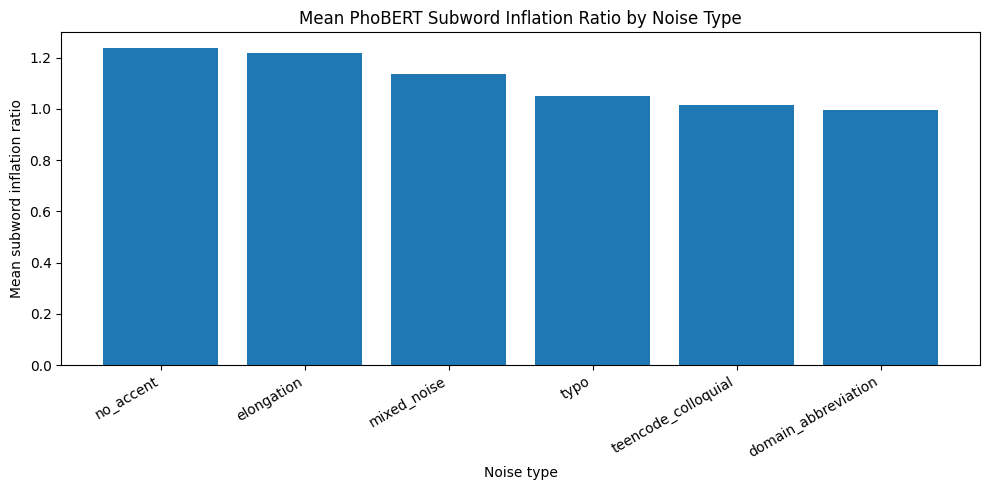

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\05_subword_inflation_by_noise_type.png


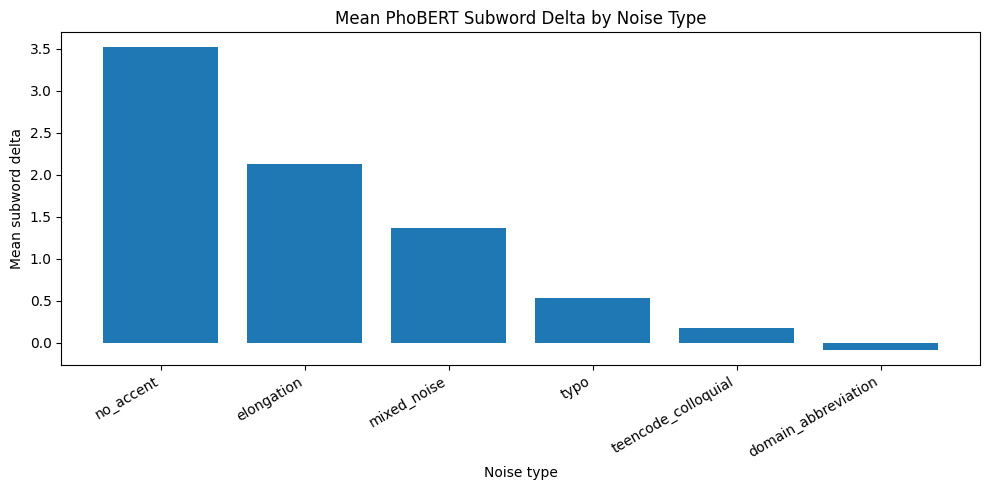

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\05_subword_delta_by_noise_type.png


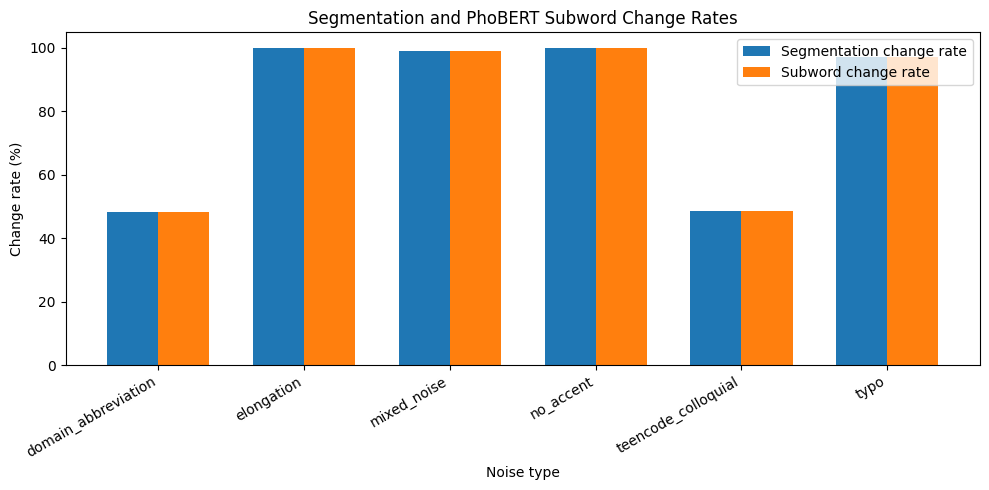

Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\05_segmentation_subword_change_rate.png


In [7]:
# Figure 1: mean subword inflation ratio by noise type
plot_df = summary_df.sort_values("mean_subword_inflation_ratio", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["noise_type"], plot_df["mean_subword_inflation_ratio"])
plt.title("Mean PhoBERT Subword Inflation Ratio by Noise Type")
plt.xlabel("Noise type")
plt.ylabel("Mean subword inflation ratio")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

fig_path = FIGURES_DIR / "05_subword_inflation_by_noise_type.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved:", fig_path)

# Figure 2: mean subword delta by noise type
plot_df = summary_df.sort_values("mean_subword_delta", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["noise_type"], plot_df["mean_subword_delta"])
plt.title("Mean PhoBERT Subword Delta by Noise Type")
plt.xlabel("Noise type")
plt.ylabel("Mean subword delta")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

fig_path = FIGURES_DIR / "05_subword_delta_by_noise_type.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved:", fig_path)

# Figure 3: segmentation and subword change rates
change_rate_df = summary_df[[
    "noise_type",
    "segmentation_change_rate",
    "subword_change_rate",
]].copy()

x = range(len(change_rate_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar([i - width / 2 for i in x], change_rate_df["segmentation_change_rate"], width=width, label="Segmentation change rate")
plt.bar([i + width / 2 for i in x], change_rate_df["subword_change_rate"], width=width, label="Subword change rate")
plt.title("Segmentation and PhoBERT Subword Change Rates")
plt.xlabel("Noise type")
plt.ylabel("Change rate (%)")
plt.xticks(list(x), change_rate_df["noise_type"], rotation=30, ha="right")
plt.legend()
plt.tight_layout()

fig_path = FIGURES_DIR / "05_segmentation_subword_change_rate.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved:", fig_path)


## 8. Generate Stage 5 report

In [8]:
def dataframe_to_markdown(df: pd.DataFrame) -> str:
    if df.empty:
        return "_Empty table_"

    safe_df = df.copy()
    for col in safe_df.columns:
        if pd.api.types.is_float_dtype(safe_df[col]):
            safe_df[col] = safe_df[col].round(4)
        safe_df[col] = safe_df[col].astype(str)

    headers = safe_df.columns.tolist()
    lines = []
    lines.append("| " + " | ".join(headers) + " |")
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")

    for _, row in safe_df.iterrows():
        lines.append("| " + " | ".join(row[col] for col in headers) + " |")

    return "\n".join(lines)

report_lines = []

report_lines.append("# Segmentation and PhoBERT Tokenization Analysis Report\n")
report_lines.append(f"- Created at: `{datetime.now().isoformat(timespec='seconds')}`")
report_lines.append("- Stage: `05_segmentation_tokenization_analysis`")
report_lines.append(f"- Clean test split: `{CLEAN_TEST_PATH}`")
report_lines.append(f"- Noisy data directory: `{NOISY_DIR}`")
report_lines.append(f"- Segmentation method: `{segmenter.method}`")
report_lines.append(f"- Tokenizer source: `{tokenizer.source}`")
report_lines.append("- Model evaluation is not performed in Stage 5.\n")

report_lines.append("## Analysis scope\n")
report_lines.append("- Compare `original_text` and `noisy_text` from each Stage 4 noisy test set.")
report_lines.append("- Measure segmentation/word-count change.")
report_lines.append("- Measure PhoBERT subword tokenization change.")
report_lines.append("- Identify examples with large subword inflation.\n")

report_lines.append("## Metric definitions\n")
report_lines.append("- `segment_delta`: `num_segments_noisy - num_segments_clean`.")
report_lines.append("- `subword_delta`: `num_subwords_noisy - num_subwords_clean`.")
report_lines.append("- `subword_inflation_ratio`: `num_subwords_noisy / num_subwords_clean`.")
report_lines.append("- `segmentation_change_rate`: percentage of rows whose segment sequence changed.")
report_lines.append("- `subword_change_rate`: percentage of rows whose PhoBERT subword sequence changed.\n")

report_lines.append("## Summary by noise type\n")
summary_cols = [
    "noise_type",
    "num_rows",
    "num_changed_rows",
    "mean_changed_token_ratio",
    "mean_segment_delta",
    "segmentation_change_rate",
    "mean_subword_delta",
    "mean_subword_inflation_ratio",
    "subword_change_rate",
]
report_lines.append(dataframe_to_markdown(summary_df[summary_cols]))
report_lines.append("\n")

if not changed_only_summary.empty:
    report_lines.append("## Changed-only summary\n")
    changed_cols = [
        "noise_type",
        "num_changed_subset_rows",
        "mean_changed_token_ratio",
        "mean_segment_delta",
        "segmentation_change_rate",
        "mean_subword_delta",
        "mean_subword_inflation_ratio",
        "subword_change_rate",
    ]
    report_lines.append(dataframe_to_markdown(changed_only_summary[changed_cols]))
    report_lines.append("\n")

report_lines.append("## Interpretation notes\n")
report_lines.append("- `no_accent` is a systematic transformation. A high tokenization change rate should be interpreted as broad diacritic removal, not necessarily semantic corruption.")
report_lines.append("- `domain_abbreviation` and `teencode_colloquial` may contain many unchanged rows because only sentences matching the configured rules are transformed.")
report_lines.append("- Changed-only statistics are useful for isolating the effect of rows that were actually modified.")
report_lines.append("- This stage does not conclude which model is more robust; that is handled in Stage 6.\n")

report_lines.append("## Limitations\n")
report_lines.append("- The default segmentation method is whitespace unless an external Vietnamese segmenter is configured.")
report_lines.append("- PhoBERT tokenizer analysis is performed directly on the clean/noisy text produced by Stage 4.")
report_lines.append("- Manual semantic validation of all noisy samples is not performed in this project scope.\n")

report_path = NOTES_DIR / "05_segmentation_tokenization_report.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")

print("Saved:", report_path)


Saved: d:\project-ml-engineering\nlp-phobert-student-feedback\reports\notes\05_segmentation_tokenization_report.md


## 9. Final Stage 5 output check

In [9]:
expected_files = [
    TABLES_DIR / "05_segmentation_tokenization_analysis.csv",
    TABLES_DIR / "05_segmentation_tokenization_summary.csv",
    TABLES_DIR / "05_segmentation_tokenization_changed_only_summary.csv",
    TABLES_DIR / "05_high_subword_inflation_examples.csv",
    FIGURES_DIR / "05_subword_inflation_by_noise_type.png",
    FIGURES_DIR / "05_subword_delta_by_noise_type.png",
    FIGURES_DIR / "05_segmentation_subword_change_rate.png",
    NOTES_DIR / "05_segmentation_tokenization_report.md",
]

for noise_type in noisy_frames.keys():
    expected_files.append(TABLES_DIR / f"05_tokenization_analysis_{noise_type}.csv")

print("Stage 5 output check:")

all_ok = True
for path in expected_files:
    exists = path.exists()
    all_ok = all_ok and exists
    print("[OK]     " if exists else "[MISSING]", path)

print("\nStage 5 completed:", all_ok)


Stage 5 output check:
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\05_segmentation_tokenization_analysis.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\05_segmentation_tokenization_summary.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\05_segmentation_tokenization_changed_only_summary.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\tables\05_high_subword_inflation_examples.csv
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\05_subword_inflation_by_noise_type.png
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\05_subword_delta_by_noise_type.png
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\figures\05_segmentation_subword_change_rate.png
[OK]      d:\project-ml-engineering\nlp-phobert-student-feedback\reports\notes\05_segmentation_tokenization_report.md
[OK]   

## What to send for review

After this notebook finishes, send:

1. `reports/tables/05_segmentation_tokenization_summary.csv`
2. `reports/tables/05_segmentation_tokenization_changed_only_summary.csv`
3. `reports/tables/05_high_subword_inflation_examples.csv`
4. `reports/notes/05_segmentation_tokenization_report.md`
5. Final output check text
